In [26]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, f1_score, confusion_matrix

### Red wine prediction

In [2]:
# read the red wine CSV
df_red = pd.read_csv("Lecture_4_Data/winequality-red.csv", sep = ';')
df_red

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
# split our data to independent and dependent variables
X = df_red.drop('quality', axis = 1)
y = df_red['quality']

In [7]:
# prepare our train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

In [10]:
# establish baseline performance

# Step 1: Declare variable with model Object
dummy = DummyRegressor()
# Step 2: Fit the train data in the model
dummy.fit(X_train, y_train)
# Step 3: Make a prediction using the trained model
dummy_pred = dummy.predict(X_test)

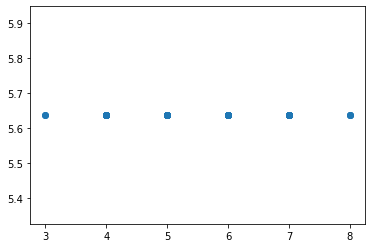

In [11]:
# Step 4: Assess model performance with plot
plt.scatter(y_test, dummy_pred)

In [12]:
# Step 5: Measure the RMSE between actual and predicted
np.sqrt(mean_squared_error(y_test, dummy_pred))

0.8033112955278268

In [14]:
# Train a LinearRegression model
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

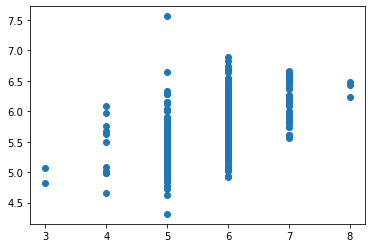

In [15]:
# Plot y_test vs lr_pred
plt.scatter(y_test, lr_pred)

In [16]:
np.sqrt(mean_squared_error(y_test, lr_pred))

0.6686463894047554

In [18]:
# Train a DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

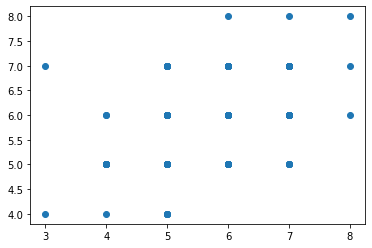

In [19]:
plt.scatter(y_test, dt_pred)

In [20]:
np.sqrt(mean_squared_error(y_test, dt_pred))

0.739509972887452

In [ ]:
# Take 6 minutes to try RandomForest
# Brb at 640pm

In [21]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

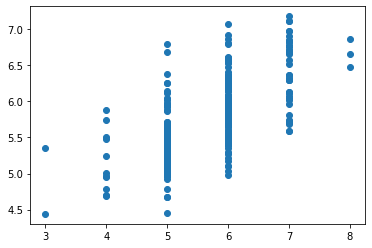

In [22]:
plt.scatter(y_test, rf_pred)

In [23]:
np.sqrt(mean_squared_error(y_test, rf_pred))

0.580710233248907

In [30]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

In [33]:
f1_score(y_test, dummy_pred, average = 'micro')

0.425

In [34]:
confusion_matrix(y_test, dummy_pred)

array([[  0,   0,   2,   0,   0,   0],
       [  0,   0,  11,   0,   0,   0],
       [  0,   0, 136,   0,   0,   0],
       [  0,   0, 128,   0,   0,   0],
       [  0,   0,  40,   0,   0,   0],
       [  0,   0,   3,   0,   0,   0]], dtype=int64)

In [29]:
logr = LogisticRegression(max_iter = 10000)
logr.fit(X_train, y_train)
logr_pred = logr.predict(X_test)

In [35]:
f1_score(y_test, logr_pred, average = 'micro')

0.575

In [36]:
confusion_matrix(y_test, logr_pred)

array([[ 0,  1,  1,  0,  0,  0],
       [ 0,  0,  7,  3,  1,  0],
       [ 0,  1, 96, 38,  1,  0],
       [ 0,  0, 39, 78, 11,  0],
       [ 0,  0,  1, 29, 10,  0],
       [ 0,  0,  0,  2,  1,  0]], dtype=int64)

In [37]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [38]:
f1_score(y_test, dt_pred, average = 'micro')

0.63125

In [39]:
confusion_matrix(y_test, dt_pred)

array([[ 0,  0,  2,  0,  0,  0],
       [ 1,  1,  5,  3,  1,  0],
       [ 1,  3, 95, 27, 10,  0],
       [ 0,  1, 28, 81, 18,  0],
       [ 0,  1,  4,  9, 25,  1],
       [ 0,  0,  0,  2,  1,  0]], dtype=int64)

In [40]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [41]:
f1_score(y_test, rf_pred, average = 'micro')

0.69375

In [42]:
confusion_matrix(y_test, rf_pred)

array([[  0,   0,   2,   0,   0,   0],
       [  1,   0,   9,   1,   0,   0],
       [  0,   0, 109,  25,   2,   0],
       [  0,   0,  25,  93,  10,   0],
       [  0,   0,   0,  20,  20,   0],
       [  0,   0,   0,   2,   1,   0]], dtype=int64)

In [43]:
# Come back at 710pm sharp

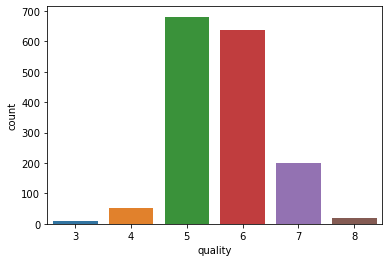

In [45]:
sns.countplot(df_red['quality'])

In [46]:
isGood = []

for quality in df_red['quality']:
    if quality >= 6:
        isGood.append(1)
    else:
        isGood.append(0)
        
df_red['isGood'] = isGood
df_red

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,isGood
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


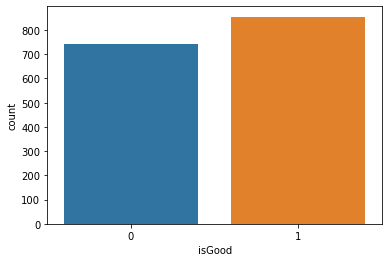

In [47]:
sns.countplot(df_red['isGood'])

In [48]:
# split our data to independent and dependent variables
X = df_red.drop(['quality', 'isGood'], axis = 1)
y = df_red['isGood']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

In [50]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

In [51]:
f1_score(y_test, dummy_pred)

0.6965376782077394

In [52]:
confusion_matrix(y_test, dummy_pred)

array([[  0, 149],
       [  0, 171]], dtype=int64)

In [53]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [54]:
f1_score(y_test, rf_pred)

0.8390804597701148

In [55]:
confusion_matrix(y_test, rf_pred)

array([[118,  31],
       [ 25, 146]], dtype=int64)

In [57]:
X.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [56]:
rf.feature_importances_

array([0.06516591, 0.10865151, 0.06332038, 0.05527218, 0.07197427,
       0.06164248, 0.10118655, 0.09677095, 0.06633115, 0.13337432,
       0.17631031])

In [59]:
pd.DataFrame({'feature': X.columns,
              'importance': rf.feature_importances_}).sort_values('importance', ascending = False)

,feature,importance
10,alcohol,0.176310
9,sulphates,0.133374
1,volatile acidity,0.108652
6,total sulfur dioxide,0.101187
7,density,0.096771
4,chlorides,0.071974
8,pH,0.066331
0,fixed acidity,0.065166
2,citric acid,0.063320
5,free sulfur dioxide,0.061642
